<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 3: *Feature Engineering*

## Metadata
---
### Contents  
> 1. *Calculate Temporal Fields*
> 2. *Calculate Lagged Weather Variables*
> 3. *Build Target*
> 4. *Fire History*
> 5. *File Export*
---
### Notes
> Features Added:
> - `Year`,`Month`,`Season` Simple temporal factors
> - `Fire_History` An average count of fires per month in a region spanning the alst two years (needs refinement)
> - `Lagged_Variables` 7 day rolling averages for key select weather factors.
---
### Inputs
- `samples_projected.csv` cleaned weather data joined with cleaned fire damage dataset
---
### Outputs 
- `engineered_samples.csv` - final clean dataset with features added
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---

### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

---

## **Load Datasets**

In [3]:
samples = pd.read_csv("../data/processed/samples_fires.csv")

---

## Calculate Temporal Fields
`Season` `Year`

In [4]:
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
    
## Apply function   
samples['Date'] = pd.to_datetime(samples['Date'])
samples['Season'] = samples['Date'].apply(get_season)
samples['Year'] = samples['Date'].dt.year

## Calculate Lagged Weather Variables

Calculate 7-day rolling averages for select weather variables to capture recent trends that may influence fire severity.

In [5]:
# Sort data by County and Date to prepare for rolling average
samples = samples.sort_values(by=['grid_id', 'Date'])

# Define columns for 7-day rolling average
avg_columns = [
    "Vapor Pressure Deficit",
    "Precipitation",
    "Solar Radiation",
    "Daily Maximum Air Temperature",
    "Daily Minimum Air Temperature",
    "Maximum Relative Humidity",
    "Minimum Relative Humidity",
    "Wind Speed"
]

# Apply rolling mean by County
for col in avg_columns:
    samples[f'{col} 7 Day Avg'] = samples.groupby('grid_id')[col].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True)

## Build Final Targets

### Fire Ignition Target

In [ ]:
def fire_risk_category(row):
    if row['fire_count'] == 0:
        return 0
    elif row['fire_count'] == 1:
        return 1
    else:
        return 2

samples['Target_Ignition'] = samples.apply(
    fire_risk_category,
    axis=1,
)

## Display resulting risk category assignments
samples['Target_Ignition'].value_counts()

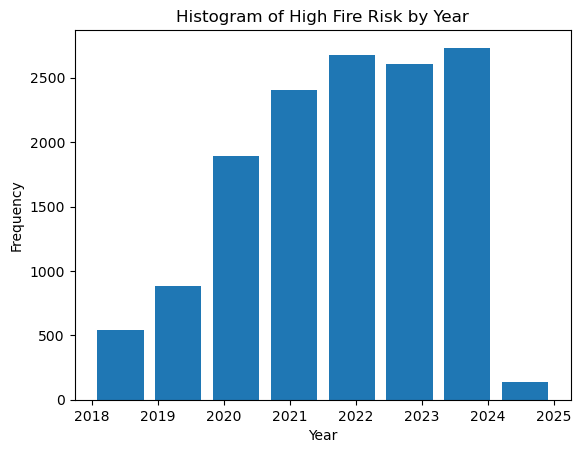

In [11]:
Risk = samples[samples['Target_Ignition']==2]

x = Risk['Year']

plt.figure()
plt.hist(x, bins=8, rwidth=0.8) 
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.title("Histogram of High Fire Risk by Year")
plt.show()

### Fire Spread Target

In [ ]:
spreading_fires = samples[samples['acres']>0]
acres_25 = spreading_fires['acres'].quantile(0.5)

def fire_spread_category(row):
    if row['acres'] == 0:
        return 0
    elif row['acres'] <= acres_25:
        return 1
    else:
        return 2

samples['Target_Spread'] = samples.apply(
    fire_spread_category,
    axis=1,
)

## Display resulting risk category assignments
samples['Target_Spread'].value_counts()

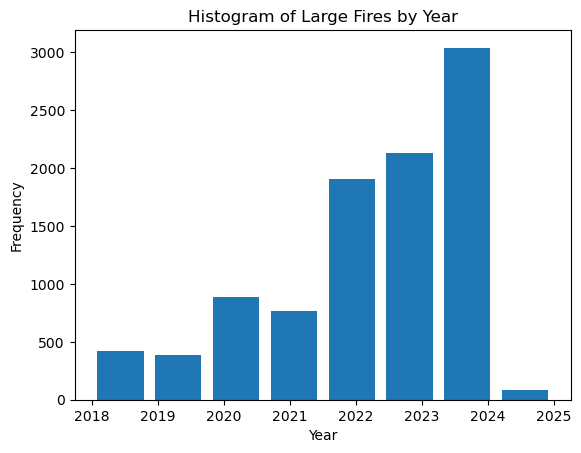

In [12]:
Spread = samples[samples['Target_Spread']==2]

x = Spread['Year']

plt.figure()
plt.hist(x, bins=8, rwidth=0.8) 
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.title("Histogram of Large Fires by Year")
plt.show()

### Fire Damage Target

Create a categorical target that represents the risk levels of damage caused.\
\
`Low` Risk = 0, No fires present on that day in a grid\
`Medium` Risk = 1, Fires present in the grid\
`High` Risk = 2, Fires present that cause financial damage or have above average acreage burns in the grid

In [6]:
def fire_damage_category(row):
    if row['total_fire_damage'] == 0:
        return 0
    else:
        return 1

samples['Target_Damage'] = samples.apply(
    fire_damage_category,
    axis=1,
)

## Display resulting risk category assignments
samples['Target_Damage'].value_counts()

Target_Damage
0    608352
1       528
Name: count, dtype: int64

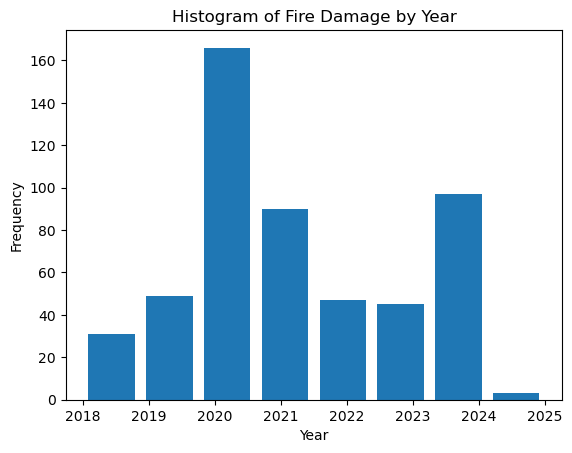

In [10]:
severe = samples[samples['Target_Damage']==1]

x = severe['Year']

plt.figure()
plt.hist(x, bins=8, rwidth=0.8) 
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.title("Histogram of Fire Damage by Year")
plt.show()

## Santa Ana Score

`Wind speed x degree of dryness` An experimental score to capture the influence of the Santa Ana winds.

In [13]:
samples['Santa_Ana_Score'] = (
    samples['Wind Speed'] * (100 - samples['Minimum Relative Humidity']) / 100
)

## Interaction Features

### (TODO) Expand interaction definitions

In [14]:
# Define interaction pairs
interactions = [
    ("Wind Speed", "100-hour Dead Fuel Moisture"), ## Fire spread
    ("Vapor Pressure Deficit", "Solar Radiation"), #
    ("Precipitation", "1000-hour Dead Fuel Moisture"), #Fire start potential
    ("northness_mean", "Daily Maximum Air Temperature"), 
    ("road_density", "forest_percent"), # interace between human density and forests
    ("power_line_density", "total_housing"), # Human environment interaction
]

In [15]:
interaction_columns = []

# Create the interaction columns for the main dataset
for v1, v2 in interactions:
    col_name = f"{v1}_x_{v2}"
    samples[col_name] = samples[v1] * samples[v2]
    interaction_columns.append(col_name)

## Wind Slope Interactions

In [16]:
topo_cols = ['slope_mean', 'slope_max', 'northness_mean', 'eastness_mean', 'elevation_mean', 'elevation_range']
wind_cols = ['Wind Speed', 'Wind Speed 7 Day Avg']
wind_slope = []

# Create the interaction columns
for v1 in wind_cols:
    for v2 in topo_cols:
        col_name = f"{v1}_x_{v2}"
        samples[col_name] = samples[v1] * samples[v2]
        wind_slope.append(col_name)

In [17]:
samples.columns = (
    samples.columns
    .str.replace("\u2013", "-", regex=False)
    .str.replace("\u2014", "-", regex=False)
)

In [23]:
engineered_samples = samples.rename(columns = {
    'Standardized Precipitation Index 30-Day': 'SPI 30-Day',
    'Standardized Precipitation Index 180-Day':'SPI 180-Day',
    'Standardized Precipitation Evapotranspiration Index 30-Day':'SPEI 30-Day',
    'Standardized Precipitation Evapotranspiration Index 90-Day':'SPEI 90-Day',
    'Standardized Precipitation Evapotranspiration Index 180-Day':'SPEI 180-Day'
})

## Export Data

In [25]:
engineered_samples.to_csv("../data/processed/engineered_samples.csv", index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
